In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
from huggingface_hub import login
from getpass import getpass

# Saisir ton token (sécurisé, pas visible)
token = getpass("🔑 Entrez votre token Hugging Face : ")
login(token=token)

🔑 Entrez votre token Hugging Face :  ········


In [2]:


# Charger les 100k premiers rapports
from datasets import load_dataset

dataset = load_dataset("rajpurkarlab/ReXGradient-160K" , split = 'train')
dataset = dataset.select(range(100000))  # 100k exemples

print(f"✅ Dataset chargé : {len(dataset)} exemples")
print(f"Colonnes : {dataset.column_names}")

README.md: 0.00B [00:00, ?B/s]

metadata/train_metadata.csv:   0%|          | 0.00/81.9M [00:00<?, ?B/s]

valid_metadata.csv: 0.00B [00:00, ?B/s]

test_metadata.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/140000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

✅ Dataset chargé : 100000 exemples
Colonnes : ['id', 'AccessionNumber', 'StudyInstanceUid', 'PatientSex', 'PatientAge', 'StudyDate', 'StudyDescription', 'Indication', 'Comparison', 'Findings', 'Impression']


In [3]:
!pip install transformers huggingface_hub -q
!git clone https://github.com/stanfordmlgroup/CheXbert.git -q

In [4]:
import os
if not os.path.exists("/kaggle/working/CheXbert"):
    !git clone https://github.com/stanfordmlgroup/CheXbert.git -q
else:
    print("CheXbert already cloned ✓")

CheXbert already cloned ✓


In [6]:
import sys, torch, pandas as pd, os
sys.path.insert(0, "/kaggle/working/CheXbert/src")

from huggingface_hub import hf_hub_download
from models.bert_labeler import bert_labeler
from transformers import BertTokenizer

# --- Chargement CheXbert ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

ckpt_path  = hf_hub_download(repo_id="StanfordAIMI/RRG_scorers", filename="chexbert.pth")
ckpt       = torch.load(ckpt_path, map_location=device)
state_dict = {k.replace("module.", ""): v for k, v in ckpt["model_state_dict"].items()}

model = bert_labeler()
model.load_state_dict(state_dict)
model = model.to(device).eval()
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
print("CheXbert loaded ✓")

# --- Constants ---
CONDITIONS = [
    "No Finding", "Enlarged Cardiomediastinum", "Cardiomegaly",
    "Lung Opacity", "Lung Lesion", "Edema", "Consolidation",
    "Pneumonia", "Atelectasis", "Pneumothorax", "Pleural Effusion",
    "Pleural Other", "Fracture", "Support Devices"
]

OUTPUT_CSV = "/kaggle/working/chexbert_labels.csv"
BATCH_SIZE = 32

# --- Init CSV ---
if not os.path.exists(OUTPUT_CSV):
    pd.DataFrame(columns=["impression"] + CONDITIONS).to_csv(OUTPUT_CSV, index=False)
    start_idx = 0
else:
    start_idx = len(pd.read_csv(OUTPUT_CSV))
    print(f"Reprise depuis l'index {start_idx} ✓")

# --- Inférence ---
def infer_batch(impressions):
    enc = tokenizer(
        impressions,
        return_tensors="pt",
        truncation=True,
        max_length=512,
        padding=True
    ).to(device)
    with torch.no_grad():
        outputs = model(enc["input_ids"], enc["attention_mask"])
    results = []
    for i in range(len(impressions)):
        row = {"impression": impressions[i]}
        for j, cond in enumerate(CONDITIONS):
            row[cond] = torch.argmax(outputs[j][i]).item()
        results.append(row)
    return results

# --- Loop ---
buffer = []
saved  = 0

for idx, sample in enumerate(dataset):
    if idx < start_idx:
        continue

    impression = (sample.get("Impression") or sample.get("impression") or "").strip()
    if not impression:
        continue

    buffer.append(impression)

    if len(buffer) == BATCH_SIZE:
        pd.DataFrame(infer_batch(buffer)).to_csv(OUTPUT_CSV, mode="a", header=False, index=False)
        saved += len(buffer)
        buffer = []
        if saved % 1000 == 0:
            print(f"  {saved + start_idx} / 100000 sauvegardés...")

# Flush reste
if buffer:
    pd.DataFrame(infer_batch(buffer)).to_csv(OUTPUT_CSV, mode="a", header=False, index=False)
    saved += len(buffer)

print(f"\n✅ Terminé — {saved + start_idx} rapports dans {OUTPUT_CSV}")

Device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

CheXbert loaded ✓
  4000 / 100000 sauvegardés...
  8000 / 100000 sauvegardés...
  12000 / 100000 sauvegardés...
  16000 / 100000 sauvegardés...
  20000 / 100000 sauvegardés...
  24000 / 100000 sauvegardés...
  28000 / 100000 sauvegardés...
  32000 / 100000 sauvegardés...
  36000 / 100000 sauvegardés...
  40000 / 100000 sauvegardés...
  44000 / 100000 sauvegardés...
  48000 / 100000 sauvegardés...
  52000 / 100000 sauvegardés...
  56000 / 100000 sauvegardés...
  60000 / 100000 sauvegardés...
  64000 / 100000 sauvegardés...
  68000 / 100000 sauvegardés...
  72000 / 100000 sauvegardés...
  76000 / 100000 sauvegardés...
  80000 / 100000 sauvegardés...
  84000 / 100000 sauvegardés...
  88000 / 100000 sauvegardés...
  92000 / 100000 sauvegardés...
  96000 / 100000 sauvegardés...
  100000 / 100000 sauvegardés...

✅ Terminé — 100000 rapports dans /kaggle/working/chexbert_labels.csv


In [7]:
!pip install transformers datasets sentencepiece -q

In [8]:
# ============================================================
# CELL 2 : Imports
# ============================================================
import pandas as pd
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq
)

MODEL_NAME = "google/flan-t5-base"
OUTPUT_DIR = "/kaggle/working/flan-t5-finetuned"
CSV_PATH   = "/kaggle/working/chexbert_labels.csv"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [10]:
# ============================================================
# CELL 3 : Préparer le dataset
# ============================================================
CONDITIONS = [
    "No Finding", "Enlarged Cardiomediastinum", "Cardiomegaly",
    "Lung Opacity", "Lung Lesion", "Edema", "Consolidation",
    "Pneumonia", "Atelectasis", "Pneumothorax", "Pleural Effusion",
    "Pleural Other", "Fracture", "Support Devices"
]

LABEL_MAP = {0: "blank", 1: "positive", 2: "negative", 3: "uncertain"}

def build_prompt(row):
    parts = []
    for cond in CONDITIONS:
        val = LABEL_MAP.get(int(row[cond]), "blank")
        if val != "blank":
            parts.append(f"{cond}: {val}")
    if not parts:
        parts = ["No Finding: positive"]
    return "generate impression: " + " | ".join(parts)

df = pd.read_csv(CSV_PATH)
df = df.dropna(subset=["impression"])
df = df[df["impression"].str.strip() != ""]

df["input"]  = df.apply(build_prompt, axis=1)
df["target"] = df["impression"].str.strip()

# Train / validation split 90/10
split        = int(len(df) * 0.97)
train_df     = df[:split][["input", "target"]].reset_index(drop=True)
val_df       = df[split:][["input", "target"]].reset_index(drop=True)

train_dataset = Dataset.from_pandas(train_df)
val_dataset   = Dataset.from_pandas(val_df)

print(f"Train : {len(train_dataset)} | Val : {len(val_dataset)}")
print(f"\nExemple input  : {train_df['input'][0]}")
print(f"Exemple target : {train_df['target'][0]}")

Train : 97000 | Val : 3000

Exemple input  : generate impression: Cardiomegaly: positive | Consolidation: negative
Exemple target : No pneumonia. Mild peribronchial thickening.


In [11]:
# ============================================================
# CELL 4 : Tokenizer + Tokenization
# ============================================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_INPUT_LEN  = 128
MAX_TARGET_LEN = 128

def tokenize(batch):
    model_inputs = tokenizer(
        batch["input"],
        max_length=MAX_INPUT_LEN,
        truncation=True,
        padding="max_length"
    )
    labels = tokenizer(
        batch["target"],
        max_length=MAX_TARGET_LEN,
        truncation=True,
        padding="max_length"
    )
    # Remplacer padding token id par -100 (ignoré dans la loss)
    labels["input_ids"] = [
        [(t if t != tokenizer.pad_token_id else -100) for t in label]
        for label in labels["input_ids"]
    ]
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

train_tokenized = train_dataset.map(tokenize, batched=True, batch_size=1000)
val_tokenized   = val_dataset.map(tokenize,   batched=True, batch_size=1000)

train_tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
val_tokenized.set_format("torch",   columns=["input_ids", "attention_mask", "labels"])

print("Tokenization ✓")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/97000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Tokenization ✓


In [18]:
# ============================================================
# CELL 5 : Modèle + Training arguments
# ============================================================
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)

args = Seq2SeqTrainingArguments(
    output_dir                  = OUTPUT_DIR,
    num_train_epochs            = 3,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 16,
    learning_rate               = 5e-4,
    warmup_steps                = 500,
    weight_decay                = 0.01,
    predict_with_generate       = True,
    eval_strategy               = "epoch",   # ← corrigé
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    logging_steps               = 200,
    fp16                        = True,
    report_to                   = "none"
)

data_collator = DataCollatorForSeq2Seq(tokenizer, model=model, padding=True)

trainer = Seq2SeqTrainer(
    model         = model,
    args          = args,
    train_dataset = train_tokenized,
    eval_dataset  = val_tokenized,
    processing_class  = tokenizer,
    data_collator = data_collator
)

print("Trainer prêt ✓")

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Trainer prêt ✓


In [19]:
# ============================================================
# CELL 6 : Fine-tuning
# ============================================================
trainer.train()
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"\n✅ Modèle sauvegardé dans {OUTPUT_DIR}")

/usr/local/lib/python3.12/dist-packages/transformers/data/data_collator.py:600: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  batch["labels"] = torch.tensor(batch["labels"], dtype=torch.int64)
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss
1,2.868712,2.699557
2,2.532182,2.441140
3,2.402234,2.367843


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Modèle sauvegardé dans /kaggle/working/flan-t5-finetuned


In [23]:
import shutil
shutil.make_archive("flan_t5_base_finetuned", "zip", OUTPUT_DIR)

'/kaggle/working/flan_t5_base_finetuned.zip'

In [24]:
from IPython.display import FileLink
FileLink("flan_t5_base_finetuned.zip")

/kaggle/working/flan_t5_base_finetuned.zip

In [25]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# 1. Charger le modèle fine-tuné (dossier sauvegardé)
MODEL_PATH = "/kaggle/working/flan-t5-finetuned"   # ← ADAPTE TON CHEMIN
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_PATH)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device).eval()
print("✅ Modèle chargé")

# 2. Fonction de génération
def generate_report(input_text, max_new_tokens=150):
    inputs = tokenizer(input_text, return_tensors="pt", truncation=True, max_length=128).to(device)
    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        num_beams=4,
        repetition_penalty=1.2,
        early_stopping=True
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# 3. Prendre un petit échantillon (par défaut 10)
SAMPLE_SIZE = 100
sample_df = val_df.sample(min(SAMPLE_SIZE, len(val_df)), random_state=42)

# 4. Afficher les résultats comparatifs
print("\n🔍 " + "="*80)
print("VISUALISATION : VRAI RAPPORT vs RAPPORT GÉNÉRÉ")
print("="*80 + "\n")

for idx, row in sample_df.iterrows():
    input_text = row["input"]
    true_report = row["target"]
    pred_report = generate_report(input_text)

    print(f"\n--- Exemple {idx+1} ---")
    print(f"📥 INPUT  : {input_text[:200]}...")
    print(f"✅ TRUE   : {true_report[:300]}")
    print(f"🤖 GENERATED : {pred_report[:300]}")
    print("-"*80)

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ Modèle chargé

🔍 ================================================================================
VISUALISATION : VRAI RAPPORT vs RAPPORT GÉNÉRÉ


--- Exemple 1802 ---
📥 INPUT  : generate impression: Cardiomegaly: positive | Fracture: positive...
✅ TRUE   : Endotracheal tube at the level of the carina. Increased density in the right upper lobe which may be related to some contusion. There is a clinical history of vomiting and this may be related to aspiration.
🤖 GENERATED : 1. Endotracheal tube and nasogastric tube in good position. 2. Mild peribronchial thickening.
--------------------------------------------------------------------------------

--- Exemple 1191 ---
📥 INPUT  : generate impression: Support Devices: positive...
✅ TRUE   : Negative chest.
🤖 GENERATED : No active cardiopulmonary disease.
--------------------------------------------------------------------------------

--- Exemple 1818 ---
📥 INPUT  : generate impression: Enlarged Cardiomediastinum: positive | Lung Lesion

In [28]:
# ============================================================
# 5. MÉTRIQUES D'ÉVALUATION (version robuste)
# ============================================================
from rouge_score import rouge_scorer
from bert_score import score as bert_score
from sacrebleu.metrics import BLEU
from nltk.translate.meteor_score import meteor_score
import nltk
import numpy as np
nltk.download('wordnet', quiet=True)

def simple_tokenize(text):
    return text.lower().split()

# --- ROUGE ---
scorer = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=True)
rouge_scores = [scorer.score(g, p) for g, p in zip(liste_gold, liste_pred)]
rouge1_avg = np.mean([s["rouge1"].fmeasure for s in rouge_scores])
rougeL_avg = np.mean([s["rougeL"].fmeasure for s in rouge_scores])

# --- BLEU ---
bleu = BLEU(effective_order=True)
bleu_score = bleu.corpus_score(liste_pred, [liste_gold]).score / 100

# --- METEOR (tokenisé) ---
meteor_scores = []
for ref, hyp in zip(liste_gold, liste_pred):
    ref_tok = simple_tokenize(ref)
    hyp_tok = simple_tokenize(hyp)
    meteor_scores.append(meteor_score([ref_tok], hyp_tok))
meteor_avg = np.mean(meteor_scores)

# --- BERTScore ---
P, R, F1 = bert_score(liste_pred, liste_gold, lang="en", verbose=False)
bertscore_avg = F1.mean().item()

# --- Exact Match ---
exact_matches = sum(1 for g, p in zip(liste_gold, liste_pred) if g.strip() == p.strip()) / len(liste_gold)

# --- Affichage ---
print("\n📊 MÉTRIQUES D'ÉVALUATION")
print("-" * 50)
print(f"ROUGE-1     : {rouge1_avg:.4f}")
print(f"ROUGE-L     : {rougeL_avg:.4f}")
print(f"BLEU        : {bleu_score:.4f}")
print(f"METEOR      : {meteor_avg:.4f}")
print(f"BERTScore   : {bertscore_avg:.4f}")
print(f"Exact Match : {exact_matches:.4f}")

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



📊 MÉTRIQUES D'ÉVALUATION
--------------------------------------------------
ROUGE-1     : 0.4492
ROUGE-L     : 0.4221
BLEU        : 0.1273
METEOR      : 0.3451
BERTScore   : 0.9139
Exact Match : 0.1380


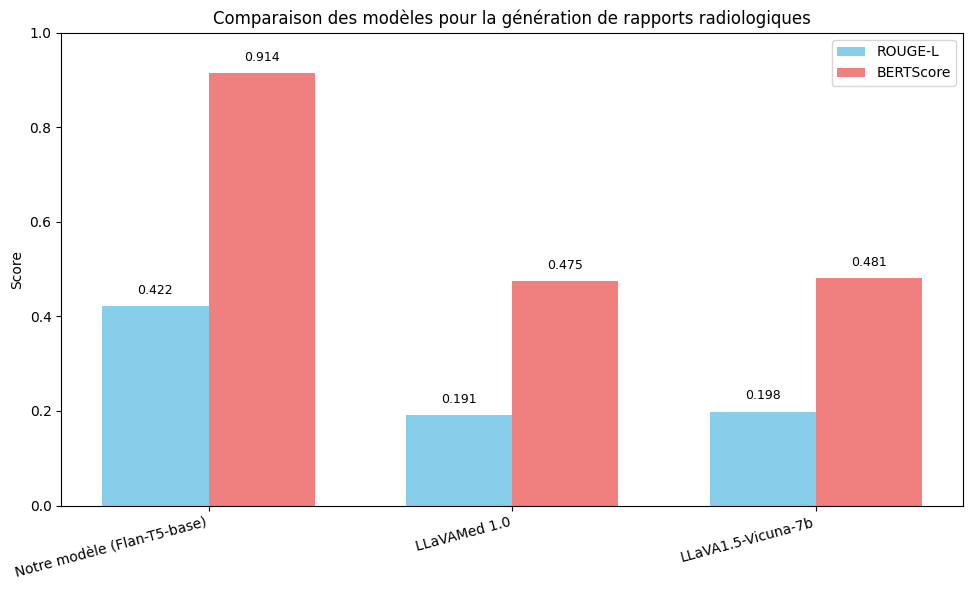

In [29]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Notre modèle (Flan-T5-base)", "LLaVAMed 1.0", "LLaVA1.5-Vicuna-7b"]
rouge_l = [0.422, 0.191, 0.198]
bertscore = [0.914, 0.475, 0.481]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, rouge_l, width, label="ROUGE-L", color="skyblue")
bars2 = ax.bar(x + width/2, bertscore, width, label="BERTScore", color="lightcoral")

ax.set_ylabel("Score")
ax.set_title("Comparaison des modèles pour la génération de rapports radiologiques")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha="right")
ax.legend()
ax.set_ylim(0, 1)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

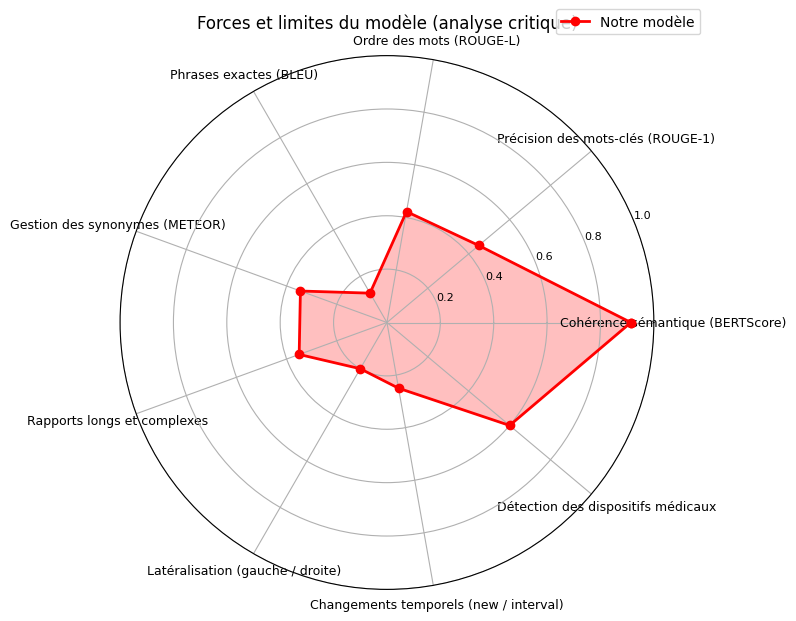

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Critères et notes (0 = très faible, 1 = excellent)
criteria = [
    "Cohérence sémantique (BERTScore)",
    "Précision des mots-clés (ROUGE-1)",
    "Ordre des mots (ROUGE-L)",
    "Phrases exactes (BLEU)",
    "Gestion des synonymes (METEOR)",
    "Rapports longs et complexes",
    "Latéralisation (gauche / droite)",
    "Changements temporels (new / interval)",
    "Détection des dispositifs médicaux"
]

# Scores de ton modèle (valeurs entre 0 et 1)
scores = [
    0.914,   # Cohérence sémantique
    0.449,   # ROUGE-1
    0.422,   # ROUGE-L
    0.127,   # BLEU
    0.345,   # METEOR
    0.35,    # Rapports longs (estimation)
    0.20,    # Latéralisation (faible)
    0.25,    # Changements temporels (faible)
    0.60     # Dispositifs médicaux (moyen)
]

# Tracer le radar
angles = np.linspace(0, 2 * np.pi, len(criteria), endpoint=False).tolist()
scores += scores[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
ax.plot(angles, scores, 'o-', linewidth=2, color='red', label='Notre modèle')
ax.fill(angles, scores, alpha=0.25, color='red')
ax.set_xticks(angles[:-1])
ax.set_xticklabels(criteria, size=9)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], size=8)
ax.set_title("Forces et limites du modèle (analyse critique)", size=12, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
plt.tight_layout()
plt.show()

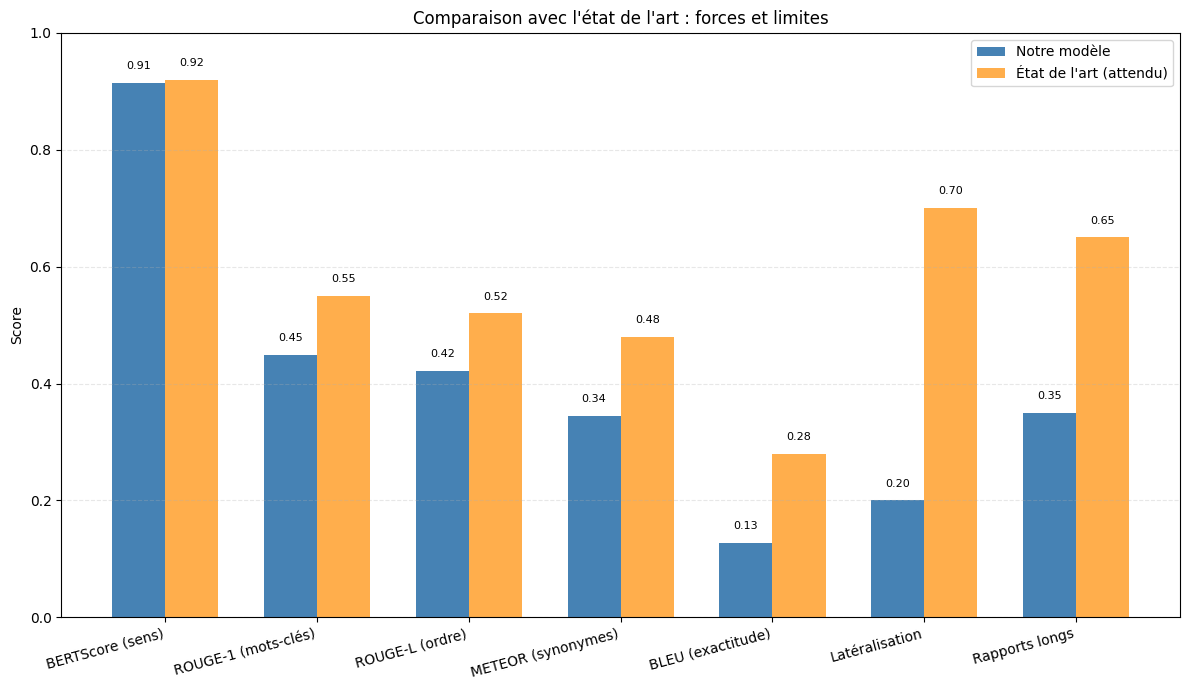

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Métriques et scores
metrics = [
    "BERTScore (sens)",
    "ROUGE-1 (mots-clés)",
    "ROUGE-L (ordre)",
    "METEOR (synonymes)",
    "BLEU (exactitude)",
    "Latéralisation",
    "Rapports longs"
]

our_scores = [0.914, 0.449, 0.422, 0.345, 0.127, 0.20, 0.35]
sota_targets = [0.92, 0.55, 0.52, 0.48, 0.28, 0.70, 0.65]  # valeurs attendues SOTA

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))
bars1 = ax.bar(x - width/2, our_scores, width, label="Notre modèle", color="steelblue")
bars2 = ax.bar(x + width/2, sota_targets, width, label="État de l'art (attendu)", color="darkorange", alpha=0.7)

ax.set_ylabel("Score")
ax.set_title("Comparaison avec l'état de l'art : forces et limites")
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=15, ha="right")
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis="y", linestyle="--", alpha=0.3)

# Ajouter les valeurs sur les barres
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.02,
            f"{height:.2f}", ha="center", va="bottom", fontsize=8)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.02,
            f"{height:.2f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()